# Notebook 0: PyTorch Fundamentals

**UCU Deep Learning Course**

Welcome! Before diving into deep learning models, we need to get comfortable with **PyTorch** — the framework we'll use throughout the course.

### What you'll learn
1. Set up your environment with `pyenv` and `uv`
2. **Tensors** — PyTorch's core data structure
3. **Datasets and DataLoaders** — feeding data to models
4. **`nn.Module`** — building neural networks
5. **Training loop** — the full workflow

---

### Resources

| Tool | Link |
|------|------|
| PyTorch documentation | [pytorch.org/docs/stable](https://pytorch.org/docs/stable/index.html) |
| PyTorch cheat sheet | [pytorch.org/tutorials/beginner/ptcheat](https://pytorch.org/tutorials/beginner/ptcheat.html) |
| PyTorch beginner tutorial | [pytorch.org/tutorials/beginner/basics](https://pytorch.org/tutorials/beginner/basics/intro.html) |
| uv documentation | [docs.astral.sh/uv](https://docs.astral.sh/uv/) |
| pyenv GitHub | [github.com/pyenv/pyenv](https://github.com/pyenv/pyenv) |

---

## Part 0 — Local Environment Setup (skip in Colab)

We use **pyenv** to manage Python versions and **uv** as a fast package manager. This keeps your environment reproducible.

### Install pyenv

> **Docs:** [pyenv GitHub](https://github.com/pyenv/pyenv) · [pyenv Wiki](https://github.com/pyenv/pyenv/wiki)

`pyenv` lets you install and switch between multiple Python versions without touching your system Python. This is essential because different projects often require different Python versions, and your OS Python should never be modified.


#### Why pyenv?

- Keeps your system Python untouched and safe
- Lets you pin an exact Python version per project via a `.python-version` file
- Works on macOS, Linux, and WSL

#### Installation

**macOS (Homebrew):**

```bash
brew install pyenv
```

**Linux / WSL:**

```bash
curl https://pyenv.run | bash
```

After installation, add the following lines to your shell config (`~/.zshrc` on macOS, `~/.bashrc` on Linux):

```bash
export PYENV_ROOT="$HOME/.pyenv"
export PATH="$PYENV_ROOT/bin:$PATH"
eval "$(pyenv init -)"
```

Then reload your shell:

```bash
source ~/.zshrc   # or ~/.bashrc on Linux
```

#### Set Python 3.12

```bash
pyenv install 3.12       # download and build Python 3.12
pyenv global 3.12        # set it as the default version
python --version         # should print: Python 3.12.x
```

You can also use `pyenv local 3.12` inside a project directory to pin the version only for that project — that is exactly what the `.python-version` file in this repo does.


### Install uv

> **Docs:** [docs.astral.sh/uv](https://docs.astral.sh/uv/) · [uv GitHub](https://github.com/astral-sh/uv)

`uv` is an extremely fast Python package and project manager written in Rust. It replaces `pip`, `pip-tools`, `virtualenv`, and `poetry` with a single, consistent tool.

#### Why uv?

- 10–100× faster than `pip` for dependency resolution and installation
- Creates and manages virtual environments automatically
- Declares dependencies in `pyproject.toml` and produces a reproducible `uv.lock`

#### Installation

```bash
curl -LsSf https://astral.sh/uv/install.sh | sh
```

Or via Homebrew:

```bash
brew install uv
```

Verify the installation:

```bash
uv --version
```

#### Using uv in this course

The repo already has a `pyproject.toml` and a `uv.lock` file. To get your environment ready, just run:

```bash
uv sync
```

This will create a `.venv` folder and install all dependencies (including PyTorch) at the pinned versions.

To run a script:

```bash
uv run python script.py
```

To start a Jupyter notebook:

```bash
uv run jupyter notebook
```

> **Tip:** You never need to activate the virtual environment manually — `uv run` handles it for you.

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install torch torchvision --quiet

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {device}")

torch.manual_seed(42)

PyTorch version : 2.10.0
CUDA available  : False
Using device    : cpu


---
## Part 1 — Tensors

> **Docs:** [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html) · [Tensor creation ops](https://pytorch.org/docs/stable/torch.html#creation-ops) · [Math ops](https://pytorch.org/docs/stable/torch.html#math-operations)

A **tensor** is the fundamental data structure in PyTorch. Think of it as an N-dimensional array (like NumPy) that can also:
- live on a **GPU** for fast parallel computation
- track **gradients** for automatic differentiation

| Rank | Name | Shape example |
|------|------|---------------|
| 0 | Scalar | `()` |
| 1 | Vector | `(n,)` |
| 2 | Matrix | `(m, n)` |
| 3+ | Tensor | `(batch, channels, height, width)` |

### 1.1 Creating Tensors

In [3]:
# From a Python list
a = torch.tensor([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])
print(f'a:\n{a}')
print(f'  shape: {a.shape}  dtype: {a.dtype}  ndim: {a.ndim}\n')

# Built-in constructors
print('zeros(2,3):\n', torch.zeros(2, 3))
print('ones(2,3):\n',  torch.ones(2, 3))
print('rand(2,3):\n',  torch.rand(2, 3))    # uniform [0, 1)
print('randn(2,3):\n', torch.randn(2, 3))   # standard normal
print('arange(0,10,2):', torch.arange(0, 10, 2))

a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
  shape: torch.Size([2, 3])  dtype: torch.float32  ndim: 2

zeros(2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones(2,3):
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
rand(2,3):
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])
randn(2,3):
 tensor([[ 1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808]])
arange(0,10,2): tensor([0, 2, 4, 6, 8])


In [4]:
# Interoperability with NumPy
arr = np.array([1.0, 2.0, 3.0])
t_from_np = torch.from_numpy(arr)   # shares memory!
back_to_np = t_from_np.numpy()

print('NumPy -> Tensor:', t_from_np)
print('Tensor -> NumPy:', back_to_np)

# Shared memory: modifying one modifies the other
t_from_np[0] = 99
print(f'After t[0]=99, arr[0] = {arr[0]}')

NumPy -> Tensor: tensor([1., 2., 3.], dtype=torch.float64)
Tensor -> NumPy: [1. 2. 3.]
After t[0]=99, arr[0] = 99.0


### 1.2 Operations and Reshaping

In [5]:
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
y = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print('x + y:\n', x + y)           # element-wise addition
print('x * y:\n', x * y)           # element-wise multiplication
print('x @ y:\n', x @ y)           # matrix multiplication
print('x.T:\n',   x.T)             # transpose
print('x.sum():', x.sum().item())
print('x.mean(dim=0):', x.mean(dim=0))  # column-wise mean

x + y:
 tensor([[ 6.,  8.],
        [10., 12.]])
x * y:
 tensor([[ 5., 12.],
        [21., 32.]])
x @ y:
 tensor([[19., 22.],
        [43., 50.]])
x.T:
 tensor([[1., 3.],
        [2., 4.]])
x.sum(): 10.0
x.mean(dim=0): tensor([2., 3.])


In [6]:
t = torch.arange(12)                # [0, 1, ..., 11]
print('Original:', t.shape)          # (12,)
print('view(3,4):\n', t.view(3, 4))
print('reshape(2,2,3) shape:', t.reshape(2, 2, 3).shape)

# unsqueeze / squeeze — add or remove size-1 dimensions
v = torch.tensor([1.0, 2.0, 3.0])           # (3,)
print('unsqueeze(0):', v.unsqueeze(0).shape) # (1, 3)
print('unsqueeze(1):', v.unsqueeze(1).shape) # (3, 1)

Original: torch.Size([12])
view(3,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
reshape(2,2,3) shape: torch.Size([2, 2, 3])
unsqueeze(0): torch.Size([1, 3])
unsqueeze(1): torch.Size([3, 1])


### Exercise 1 — Tensor Manipulation (15 min)

Complete all four tasks. Do **not** use NumPy.

In [ ]:
torch.manual_seed(42)
A = torch.randn(4, 3)
b = torch.randn(3)

# (a) Compute the matrix-vector product A @ b
# Expected shape: (4,)
# YOUR CODE HERE
result_a = ...
print('(a) A @ b:', result_a)

# (b) Compute the element-wise square of A, then sum each row.
# Expected shape: (4,)
# YOUR CODE HERE
result_b = ...
print('(b) row sums of A^2:', result_b)

# (c) Compute the column-wise mean of A
# Expected shape: (3,)
# YOUR CODE HERE
result_c = ...
print('(c) column means:', result_c)

# (d) Stack A and A.T @ A into a list, then concatenate them along dim=0.
# Hint: A.T @ A has shape (3,3). Concatenate A (4,3) and A.T@A (3,3) -> shape (7,3)
# YOUR CODE HERE
result_d = ...
print('(d) concatenated shape:', result_d.shape)  # expected (7, 3)

### 1.3 Automatic Differentiation (autograd)

> **Docs:** [`torch.autograd`](https://pytorch.org/docs/stable/autograd.html) · [`torch.no_grad`](https://pytorch.org/docs/stable/generated/torch.no_grad.html) · [`Tensor.backward`](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html)

When `requires_grad=True`, PyTorch records every operation on a tensor to build a **computation graph**. Calling `.backward()` on a scalar traverses the graph in reverse and fills `.grad` on all leaf tensors.

This is the engine behind gradient-based training.

In [19]:
# f(x) = 3x^2 + 2x + 1  =>  f'(x) = 6x + 2
x = torch.tensor(2.0, requires_grad=True)
f = 3 * x**2 + 2 * x + 1

f.backward()  # computes df/dx
print(f'f(2)  = {f.item():.1f}')                     # 17.0
print(f"f'(2) = {x.grad.item():.1f}  (expected {6*2+2:.1f})")

f(2)  = 17.0
f'(2) = 14.0  (expected 14.0)


In [20]:
# During inference, disable gradient tracking to save memory
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

with torch.no_grad():
    y = x * 2
    print('requires_grad inside no_grad:', y.requires_grad)  # False

# .detach() removes a tensor from the graph without a context manager
z = (x * 2).detach()
print('requires_grad after detach:  ', z.requires_grad)      # False

requires_grad inside no_grad: False
requires_grad after detach:   False


### Exercise 2 — Gradients (10 min)

Let `f(x, y) = x²y + y³`.

1. Create `x = 1.0` and `y = 2.0` with gradient tracking.
2. Compute `z = f(x, y)` and call `.backward()`.
3. Print `x.grad` and `y.grad`.
4. Verify manually: `∂f/∂x = 2xy` and `∂f/∂y = x² + 3y²`.

In [ ]:
# YOUR CODE HERE
x = ...
y = ...
z = ...

# z.backward()
# print('x.grad =', x.grad.item(), ' expected:', ...)
# print('y.grad =', y.grad.item(), ' expected:', ...)

---
## Part 2 — Datasets and DataLoaders

> **Docs:** [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) · [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) · [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) · [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html)

PyTorch separates data loading into two abstractions:

- **`Dataset`** — defines *how to access* one sample (implement `__len__` and `__getitem__`)
- **`DataLoader`** — wraps a Dataset and handles *batching, shuffling, and parallel loading*

This separation lets you swap datasets without rewriting your training loop.

### 2.1 Built-in Dataset: FashionMNIST

In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),                   # PIL -> float tensor in [0,1]
    transforms.Normalize((0.5,), (0.5,))     # -> [-1, 1]
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

print(f'Train samples : {len(train_dataset)}')
print(f'Test  samples : {len(test_dataset)}')

image, label = train_dataset[0]
print(f'Image shape   : {image.shape}')   # (1, 28, 28)
print(f'Label         : {label}')

100.0%
100.0%
100.0%
100.0%

Train samples : 60000
Test  samples : 10000
Image shape   : torch.Size([1, 28, 28])
Label         : 9


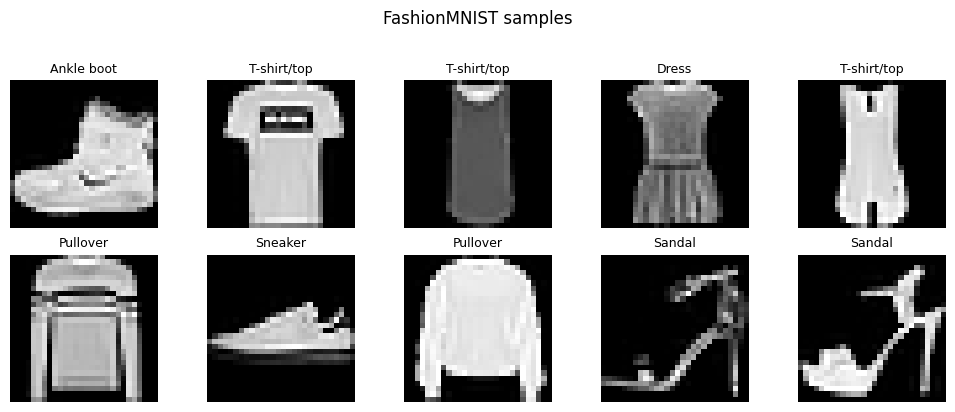

In [22]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, lbl = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[lbl], fontsize=9)
    ax.axis('off')
plt.suptitle('FashionMNIST samples', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

images, labels = next(iter(train_loader))
print(f'Batch images  : {images.shape}')   # (64, 1, 28, 28)
print(f'Batch labels  : {labels.shape}')   # (64,)

Train batches : 938
Test  batches : 157
Batch images  : torch.Size([64, 1, 28, 28])
Batch labels  : torch.Size([64])


### 2.2 Custom Dataset

Subclass `Dataset` and implement `__len__` and `__getitem__`.

Dataset length : 1000
Sample shapes  : x=torch.Size([1]), y=torch.Size([1])


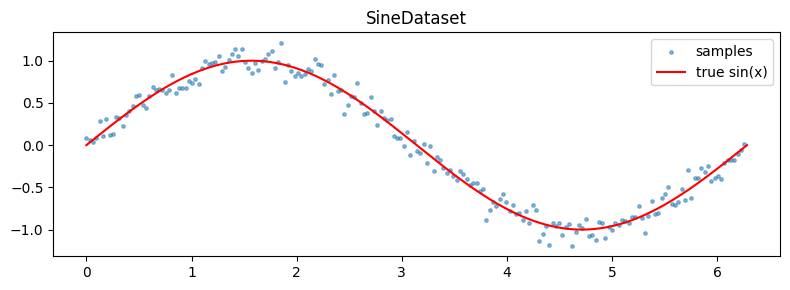

In [24]:
class SineDataset(Dataset):
    """Noisy observations of y = sin(x)."""

    def __init__(self, n_samples=1000, noise=0.1):
        self.x = torch.linspace(0, 2 * torch.pi, n_samples).unsqueeze(1)  # (N,1)
        self.y = torch.sin(self.x) + noise * torch.randn_like(self.x)     # (N,1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


sine_ds = SineDataset()
print(f'Dataset length : {len(sine_ds)}')
x0, y0 = sine_ds[0]
print(f'Sample shapes  : x={x0.shape}, y={y0.shape}')

plt.figure(figsize=(8, 3))
xs = sine_ds.x.squeeze().numpy()
ys = sine_ds.y.squeeze().numpy()
plt.scatter(xs[::5], ys[::5], s=6, alpha=0.5, label='samples')
plt.plot(xs, np.sin(xs), 'r-', label='true sin(x)')
plt.legend(); plt.title('SineDataset'); plt.tight_layout(); plt.show()

### Exercise 3 — Custom Dataset (20 min)

Implement a `TwoMoonsDataset` for binary classification.

Generate two interleaving half-circles ("moons") with the following formulas:

**Class 0** (top moon, n//2 points):  
- `θ ∈ [0, π]` linearly spaced  
- `x1 = cos(θ)`,  `x2 = sin(θ)`  

**Class 1** (bottom moon, n//2 points):  
- `θ ∈ [0, π]` linearly spaced  
- `x1 = 1 - cos(θ)`,  `x2 = 0.5 - sin(θ)`  

Add Gaussian noise (std=0.1) to all coordinates.

Requirements:
- Accept `n_samples` (default 1000) and `noise` (default 0.1) in `__init__`
- Each sample: feature tensor shape `(2,)`, label tensor shape `(1,)` with dtype `float32`
- Pass all assertions below
- Plot the dataset (two classes in different colors)

In [ ]:
class TwoMoonsDataset(Dataset):
    def __init__(self, n_samples=1000, noise=0.1):
        # YOUR CODE HERE
        pass

    def __len__(self):
        # YOUR CODE HERE
        pass

    def __getitem__(self, idx):
        # YOUR CODE HERE
        pass


# --- Assertions (do not modify) ---
torch.manual_seed(0)
moons = TwoMoonsDataset(n_samples=400)
assert len(moons) == 400, f'Expected 400, got {len(moons)}'
pt, lbl = moons[0]
assert pt.shape  == torch.Size([2]), f'Feature shape should be (2,), got {pt.shape}'
assert lbl.shape == torch.Size([1]), f'Label shape should be (1,), got {lbl.shape}'
assert lbl.dtype == torch.float32,   f'Labels must be float32'
print('All assertions passed!')

# --- Plot ---
# YOUR CODE HERE

---
## Part 3 — Building Models with `nn.Module`

> **Docs:** [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) · [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) · [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) · [Activation functions](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) · [Full `torch.nn` reference](https://pytorch.org/docs/stable/nn.html)

Every PyTorch model subclasses `nn.Module`. You implement exactly two methods:

| Method | What to do |
|--------|------------|
| `__init__` | Declare all layers and sub-modules |
| `forward(x)` | Define how data flows through them |

PyTorch tracks all registered parameters automatically — they show up in `.parameters()` and are updated by the optimizer.

In [25]:
class MLP(nn.Module):
    """Multi-Layer Perceptron."""

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = MLP(input_dim=784, hidden_dim=128, output_dim=10)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {n_params:,}')

# Test forward pass
dummy = torch.randn(32, 784)   # batch of 32 flattened 28x28 images
out   = model(dummy)
print(f'Input shape : {dummy.shape}')
print(f'Output shape: {out.shape}')   # (32, 10)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 118,282
Input shape : torch.Size([32, 784])
Output shape: torch.Size([32, 10])


In [26]:
# nn.Sequential is convenient for simple, straight-through networks
model_seq = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

print(model_seq(dummy).shape)   # (32, 10)

torch.Size([32, 10])


### Exercise 4 — Build a Classifier (10 min)

Implement `BinaryClassifier` using `nn.Module` (not `nn.Sequential`) with the following architecture:

```
Linear(input_dim → 64) → ReLU
Linear(64 → 32)        → ReLU  
Linear(32 → 1)         (no activation — we'll apply sigmoid in the loss)
```

Pass all assertions.

In [ ]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # YOUR CODE HERE
        pass

    def forward(self, x):
        # YOUR CODE HERE
        pass


# --- Assertions ---
clf = BinaryClassifier(input_dim=2)
test_out = clf(torch.randn(16, 2))
assert test_out.shape == torch.Size([16, 1]), \
    f'Expected (16, 1), got {test_out.shape}'
expected_params = 2*64+64 + 64*32+32 + 32*1+1   # = 2273
actual_params   = sum(p.numel() for p in clf.parameters())
assert actual_params == expected_params, \
    f'Expected {expected_params} params, got {actual_params}'
print(f'Assertions passed! Parameters: {actual_params}')

---
## Part 4 — The Training Loop

> **Docs:** [`torch.optim`](https://pytorch.org/docs/stable/optim.html) · [`optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) · [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) · [`nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)

The standard PyTorch training step for each batch:

```python
optimizer.zero_grad()        # 1. clear old gradients
predictions = model(x)       # 2. forward pass
loss = criterion(predictions, y)  # 3. compute loss
loss.backward()              # 4. backward pass
optimizer.step()             # 5. update parameters
```

In [31]:
# --- Train MLP on FashionMNIST ---
torch.manual_seed(42)

model     = MLP(input_dim=784, hidden_dim=128, output_dim=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.view(images.size(0), -1).to(device)  # flatten
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(images)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images  = images.view(images.size(0), -1).to(device)
            labels  = labels.to(device)
            preds   = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
    return correct / len(loader.dataset)


train_losses, test_accs = [], []
# Print metrics before testing
acc = evaluate(model, test_loader, device)
print(f'Test acc before training: {acc:.4f}')
for epoch in range(0, 6):
    loss = train_epoch(model, train_loader, criterion, optimizer, device)
    acc  = evaluate(model, test_loader, device)
    train_losses.append(loss)
    test_accs.append(acc)
    print(f'Epoch {epoch}/5 | loss: {loss:.4f} | test acc: {acc:.4f}')

Test acc before training: 0.1149
Epoch 0/5 | loss: 0.5150 | test acc: 0.8454
Epoch 1/5 | loss: 0.3800 | test acc: 0.8440
Epoch 2/5 | loss: 0.3388 | test acc: 0.8650
Epoch 3/5 | loss: 0.3138 | test acc: 0.8725
Epoch 4/5 | loss: 0.2949 | test acc: 0.8622
Epoch 5/5 | loss: 0.2801 | test acc: 0.8692


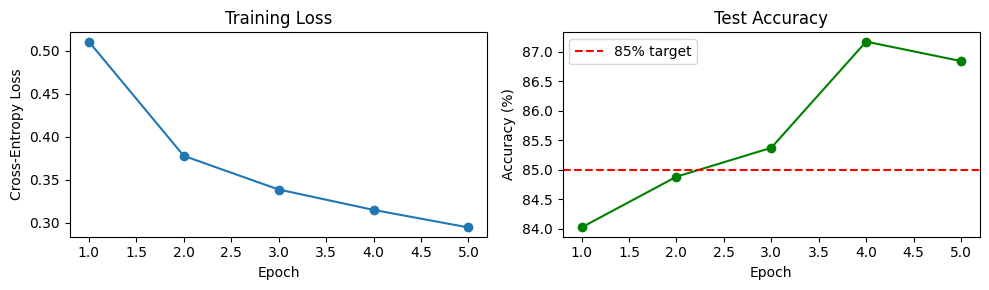

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(range(1, 6), train_losses, marker='o')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss'); ax1.set_title('Training Loss')
ax2.plot(range(1, 6), [a*100 for a in test_accs], marker='o', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Test Accuracy')
ax2.axhline(85, color='red', linestyle='--', label='85% target')
ax2.legend()
plt.tight_layout(); plt.show()

### Confusion Matrix

A **confusion matrix** is a table that summarizes how well a classifier performs across every class at once.

Each **row** represents the *actual* class; each **column** represents the *predicted* class.

|  | Predicted 0 | Predicted 1 | … |
|---|---|---|---|
| **Actual 0** | True Negatives | False Positives | … |
| **Actual 1** | False Negatives | True Positives | … |

The diagonal cells (top-left to bottom-right) are **correct** predictions. Off-diagonal cells are **errors** — they tell you *which* classes the model confuses with each other, which is much more informative than a single accuracy number.

For a 10-class problem like MNIST the matrix is 10×10: row *i*, column *j* contains the number of test images of digit *i* that the model predicted as digit *j*.

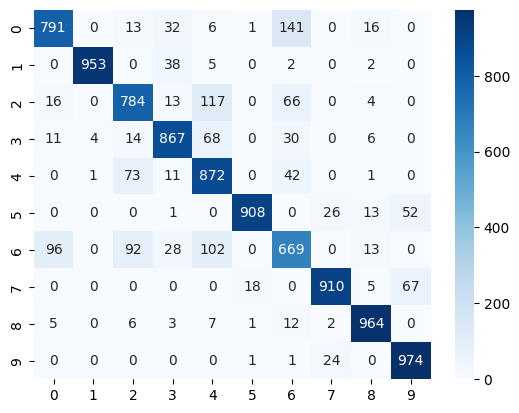

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(images.size(0), -1).to(device)
            preds = model(images).argmax(dim=1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.show()
plot_confusion_matrix(model, test_loader, device)

### Exercise 5 — End-to-End: Train on TwoMoons (25 min)

Using your `TwoMoonsDataset` (Exercise 3) and `BinaryClassifier` (Exercise 4), train a binary classifier end-to-end.

**Steps:**
1. Create a `TwoMoonsDataset` with 2000 samples. Split 80/20 into train/val using `torch.utils.data.random_split`.
2. Create `DataLoader` objects (batch size 64, shuffle train).
3. Instantiate `BinaryClassifier(input_dim=2)` and move to `device`.
4. Use `nn.BCEWithLogitsLoss` as the criterion and `torch.optim.Adam(lr=1e-3)`.
5. Train for **20 epochs**, recording train loss and val accuracy each epoch.
6. Plot the training loss curve.
7. Report final validation accuracy — you should reach **> 90%**.

> **Hint for accuracy:** `(torch.sigmoid(logits) >= 0.5).float()` gives predicted labels.

In [ ]:
torch.manual_seed(42)

# 1. Dataset + split
# YOUR CODE HERE
full_ds = ...
train_ds, val_ds = ...

# 2. DataLoaders
# YOUR CODE HERE
moons_train_loader = ...
moons_val_loader   = ...

# 3. Model
# YOUR CODE HERE
moons_model = ...

# 4. Loss + optimizer
# YOUR CODE HERE
moons_criterion = ...
moons_optimizer = ...

# 5. Training loop (20 epochs)
moons_losses, moons_accs = [], []

for epoch in range(1, 21):
    # --- train ---
    moons_model.train()
    epoch_loss = 0.0
    for x_b, y_b in moons_train_loader:
        # YOUR CODE HERE
        pass
    moons_losses.append(epoch_loss / len(train_ds))

    # --- validate ---
    moons_model.eval()
    correct = 0
    with torch.no_grad():
        for x_b, y_b in moons_val_loader:
            # YOUR CODE HERE
            pass
    moons_accs.append(correct / len(val_ds))

# 6. Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(moons_losses); ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch')
ax2.plot([a*100 for a in moons_accs], color='green')
ax2.axhline(90, color='red', linestyle='--', label='90% target')
ax2.set_title('Val Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

# 7. Final accuracy
print(f'Final validation accuracy: {moons_accs[-1]*100:.1f}%')

---
## Bonus — Activation Functions

Plot `ReLU`, `Sigmoid`, `Tanh`, and `Leaky ReLU` (negative slope=0.1) on `[-4, 4]` in the same figure.

Then answer in a markdown cell: **why can't we stack linear layers without non-linear activations?**

In [ ]:
x = torch.linspace(-4, 4, 300)

activations = {
    'ReLU':       nn.ReLU(),
    'Sigmoid':    nn.Sigmoid(),
    'Tanh':       nn.Tanh(),
    'Leaky ReLU': nn.LeakyReLU(0.1),
}

# YOUR CODE HERE — plot all four on the same axes

**Your answer here:**